In [34]:
from datetime import timedelta
import sys

In [2]:
import pandas as pd

In [4]:
%matplotlib inline

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

In [8]:
from moddata import load_data

# 1. Load the Gold Price Data 

In [9]:
data = load_data("world_bank_oil_gold_monthly_prices")
data = data[["yearmon", "gold_USD_per_troy_ounce"]].rename(columns={"gold_USD_per_troy_ounce": "gold"})
data = data.set_index("yearmon")
data = data["1960-01-01":"1971-12-02"]

In [10]:
data.head(3)

,gold
yearmon,
1960-01-01,35.27
1960-02-01,35.27
1960-03-01,35.27


# 2. Make the Plot

In [12]:
gold_fig = plt.figure(figsize=(14, 7))

<Figure size 1400x700 with 0 Axes>

In [13]:
gold_ax = gold_fig.add_subplot(111)

In [14]:
gold_ax.plot(data.index, data["gold"], color="r", drawstyle="steps-post")

In [15]:
gold_ax.set_ylim(32, 45)

(32.0, 45.0)

In [16]:
gold_ax.set_ylabel("Gold troy ounce price in USD (nominal)")
gold_ax.set_xlabel("time")

Text(0, 0.5, 'Gold troy ounce price in USD (nominal)')

In [18]:
gold_fig.suptitle("Gold Prices, Monthly Averages, in USD (nominal), Jan 1960 - Dec 1971", size=14)

Text(0.5, 0.98, 'Gold Prices, Monthly Averages, in USD (nominal), Jan 1960 - Dec 1971')

In [19]:
gold_ax.set_title(
    "Data from World Bank's Commodities Market spreadsheet, spot average of daily rates, London afternoon fixing, average of daily rates\n Plot author: Artur Wegrzyn",
    size=10
)

Text(0.5, 1.0, "Data from World Bank's Commodities Market spreadsheet, spot average of daily rates, London afternoon fixing, average of daily rates\n Plot author: Artur Wegrzyn")

In [20]:
gold_ax.xaxis.set_minor_locator(mdates.MonthLocator(7))
gold_ax.xaxis.set_major_locator(mdates.YearLocator())

In [21]:
gold_ax.xaxis.grid(which="major", linestyle="solid")
gold_ax.xaxis.grid(which="minor", linestyle="dashed")

In [22]:
gold_ax.yaxis.set_minor_locator(mticker.MultipleLocator(1))
gold_ax.yaxis.set_major_locator(mticker.MultipleLocator(2))

In [23]:
gold_ax.yaxis.grid(which="major", linestyle="solid")
gold_ax.yaxis.grid(which="minor", linestyle="dashed")

### 2.1. Cuban Missile Crisis 1962

In [42]:
# add start of Cuban missile crisis
cuban_missile_crisis = pd.Timestamp("1962-10-16")
gold_ax.axvline(cuban_missile_crisis, color="blue", linestyle="--", linewidth=1)
_ = gold_ax.annotate(
    "Cuban \nmissile crisis \n Oct 1962, 16th-28th",
    xy=(cuban_missile_crisis, 32),
    xytext=(cuban_missile_crisis - timedelta(days=60), 37),
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=1.5
    ),
    ha="right"
)

### 2.2. Kennedy's assassination 1963

In [41]:
# add date of Kennedy's assasination
kennedy = pd.Timestamp("1963-11-22")
gold_ax.axvline(kennedy, color="blue", linestyle="--", linewidth=1)
_ = gold_ax.annotate(
    "Kennedy \nassassinated \n1963-11-22",
    xy=(kennedy, 32),          # arrow target
    xytext=(kennedy + timedelta(days=120), 37),  # text position
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=1.5
    ),
    ha="left"
)

### 2.3. London Gold Pool operational 1961-1968

In [40]:
# mark period in which london gold pool existed
lgp_start = pd.Timestamp("1961-11-01")
lgp_end = pd.Timestamp("1968-03-17")
# shaded region
_ = gold_ax.axvspan(
    lgp_start,
    lgp_end,
    color="gold",
    alpha=0.25,
    label="London Gold Pool"
)

### 2.4. French Withdrawals of Gold from US 1965-1967

In [39]:
# mark period in which France withdrew its gold reserves
fr_wd_start = pd.Timestamp("1965-12-04")
fr_wd_end = pd.Timestamp("1967-06-16")
# shaded region
_ = gold_ax.axvspan(
    fr_wd_start,
    fr_wd_end,
    color="orange",
    alpha=0.25,
    label="French withdrawals of gold from US (1965-12-04 to ca. June 1967)"
)

### 2.5. Six-Day War 1967

In [38]:
# mark Six-Day War
six_day_war = pd.Timestamp("1967-06-05")
gold_ax.axvline(six_day_war, color="blue", linestyle="--", linewidth=1)
_ = gold_ax.annotate(
    "Six-Day War \n1967, 5th-10th June",
    xy=(six_day_war, 32),
    xytext=(six_day_war - timedelta(days=90), 33),
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=1.5
    ),
    ha="right"
)

### 2.6. Devaluation of Pound Sterling in 1967

In [37]:
# mark pound sterling devaluation in 1967: 1967-11-18
gbp_devalued = pd.Timestamp("1967-11-18")
gold_ax.axvline(gbp_devalued, color="blue", linestyle="--", linewidth=1)
_ = gold_ax.annotate(
    "GBP devaluation \n1967-11-18",
    xy=(gbp_devalued, 32),
    xytext=(gbp_devalued + timedelta(days=90), 33),
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=1.5
    ),
    ha="left"
)

### 2.7. Devaluation of French Franc in 1969

In [36]:
# mark French Franc (FRF) devaluation in 1969: 1969-08-08
frf_devalued = pd.Timestamp("1969-08-08")
gold_ax.axvline(frf_devalued, color="blue", linestyle="--", linewidth=1)
_ = gold_ax.annotate(
    "FRF devaluation \n1969-08-108",
    xy=(frf_devalued, 32),
    xytext=(frf_devalued + timedelta(days=90), 42),
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=1.5
    ),
    ha="left"
)

### 2.8. Nixon's Shock 1971

In [43]:
# mark nixon' shock: 1971-08-15
nixon_shock = pd.Timestamp("1971-08-15")
gold_ax.axvline(nixon_shock, color="blue", linestyle="--", linewidth=1)
_ = gold_ax.annotate(
    "Nixon's shock \n1971-08-15",
    xy=(nixon_shock, 32),
    xytext=(nixon_shock - timedelta(days=120), 33),
    arrowprops=dict(
        arrowstyle="->",
        color="blue",
        lw=1.5
    ),
    ha="right"
)

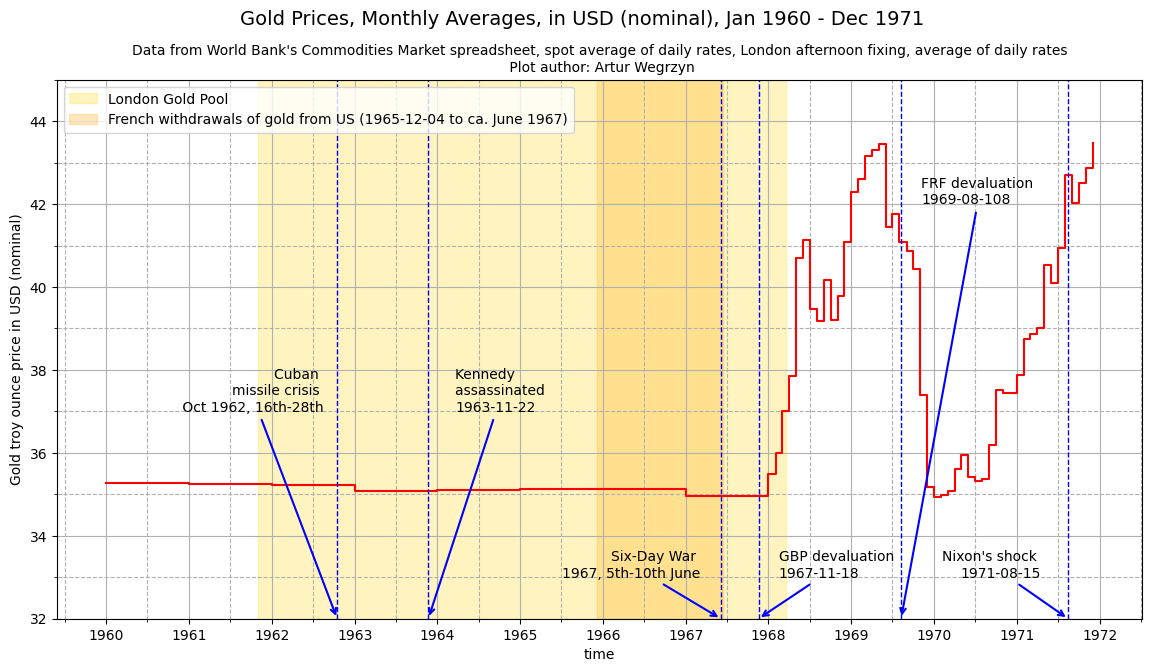

In [33]:
gold_fig

# 3. Literature References

The following materials have been used:
* Article by Jan Nieuwenhuijs [How France Secretly Repatriated All Its Gold Before Nixon's Dollar Devaluation](https://www.gullerpenger.no/publikasjoner/artikler/how-france-secretly-repatriated-all-its-gold-before-nixon-s-dollar-devaluation-2024-10-08/)
* Article by David Williams from Dec 1st, 1972: [The Gold Markets–1968-72](https://www.elibrary.imf.org/view/journals/022/0009/004/article-A002-en.xml)
* Article by Harry G. Johnson from May, 1969: [The Gold Rush of 1968 in Retrospect and Prospect](https://www.jstor.org/stable/1823687)
* Article by Michael Bordo, Eric Monnet & Alain Naef: [The Gold Pool (1961-1968) and the Fall of the Bretton Woods System. Lessons for Central Bank Cooperation.](https://www.nber.org/system/files/working_papers/w24016/w24016.pdf)
* Wikipedia article on [Six-Day War](https://en.wikipedia.org/wiki/Six-Day_War)
* Wikipedia article on [London Gold Pool](https://en.wikipedia.org/wiki/London_Gold_Pool)
* Wikipedia article on [Nixon Shock](https://en.wikipedia.org/wiki/Nixon_shock)
* Wikipedia article on [Closure of the Suez Canal (1967–1975)](https://en.wikipedia.org/wiki/Closure_of_the_Suez_Canal_(1967%E2%80%931975))
* Wikipedia article on [Petrodollar Recycling](https://en.wikipedia.org/wiki/Petrodollar_recycling)